## Análisis y Procesamiento de Señales, 2°C 2026
### Universidad Nacional de San Martín
#### Iara Alvarez Costa

# Tarea SemaN°1
Se pide simular una señal senoidal ruidosa cuyo ruido acompañante se pueda programar a través de la relación SNR entre potencias. La senoidal debe ser de 1 Watt de potencia.reo del ADC.

# Resolución:
Busco simular una señal senoidal ruidosa de 1 watt de potencia, cuyo ruido acompañante se pueda programar a través de la relación SNR entre potencias. 
Primero voy a generar una señal senoidal de la forma $x(t)=A.Sin(2π.f.t)$ donde $A$ sea su amplitud máxima. 
La potencia media de una señal se puede calcular como:
<div align="center"> $P_x =\frac{1}{T}.∫_0^Tx^2(t)  dt $ </div>

Para una senoide $Sin^2 (x)$, cuyo valor medio es $\frac{1}{2}$: $P_x =\frac{A^2}{2}$. Entonces, si quiero que la potencia media de mi señal sea de 1 Watt: $1=\frac{A^2}{2}$, y la amplitud de la señal será $A=√2$.


Ahora, también debo simular una señal de ruido para acompañar a mi senoidal. Esto lo haré generando una secuencia de números aleatorios de distribución normal con la función “$np.random.normal(µ , σ , N)$”, cuyos argumentos son $µ = $media del ruido, $σ =  $desviación estándar del ruido, y $N =$ cant. de muestras. Necesito antes que nada obtener estos valores.

Primero, para modelar una perturbación aleatoria como el ruido sin causar un desplazamiento en la señal, utilizaré una media de $µ = 0$, lo cual me permitirá relacionar la potencia del ruido con su desviación estándar de la forma $P_r=σ^2$. 
Sé que la relación entre las potencias de la señal y el ruido está dada por: 
<div align="center"> $SNR_{dB}=10.log(\frac{P_x}{P_r})$ </div>
donde $P_x$ es la potencia de mi señal $(1W)$, y $P_r$ la potencia del ruido. Entonces, si especifico el valor deseado de SNR, podré obtener $P_r=10^{-\frac{SNR_{dB}}{10}}$ y, por lo tanto, $σ=√(P_r)$.

Tengo así todos los parámetros necesarios para la generar el ruido.


In [3]:
# Importación de módulos

import numpy as np
import matplotlib.pyplot as plt


In [2]:
" ----------------------------------------------- Defino valores necesarios -----------------------------------------------"

# Ctes experimentales
fs = 1000 #Frecuencia muestreo [Hz] 
N = 1000 #Cant. muestras
ff = 3 #Frecuencia sinusoidal [Hz]

# Parámetros
vmax = np.sqrt(2) #Amp max sinusoide [V]
SNR = 10 #Valor arbitrario de SNR para probar (dB)
Psen = 1 #Potencia media senoide [Watt]
ur = 0 #Media del ruido

In [5]:
" ----------------------------------------------- Armo funciones necesarias -----------------------------------------------"

# Generador de señal senoidal
def gen_sin (vmax = 1, ff = 1, nn = N, fs = fs):

    #genero un vector de valores de 0 a N/fs segundos a intervalos de 1/fs
    tt = np.arange(0, stop=N/fs, step=1/fs)
    #genero un vector con los valores de 'vmax.Sen(2pi.ff.tt)' para cada valor de tt
    xx = vmax * np.sin (2 * np.pi * ff * tt)
    
    return tt, xx 


# Generador de ruido
def gen_noise (SNR = SNR, Psen = Psen, ur = ur, nn = N):

    #despejo la potencia del ruido en función de SNR y Psen    
    Pr = Psen / (10**(SNR/10))
     
    #calculo la desviación estandar del ruido en base a Pr (Pr = σr^2)
    desv_est_r = np.sqrt(Pr)
    
    #genero un vector de nros aleatorios de distribucion normal
    ruido = np.random.normal(ur, desv_est_r, nn)
    
    return ruido



In [7]:
" ------------------------------------------------------ Main Script ------------------------------------------------------"

#Invoco la función generadora de senoides
tt, xx = gen_sin( vmax, ff, N, fs) 

#Invoco la función generadora de ruido
ruido = gen_noise (SNR, Psen, ur, N)

#Armo manualmente la señal ruidosa
noisy_xx = xx + ruido


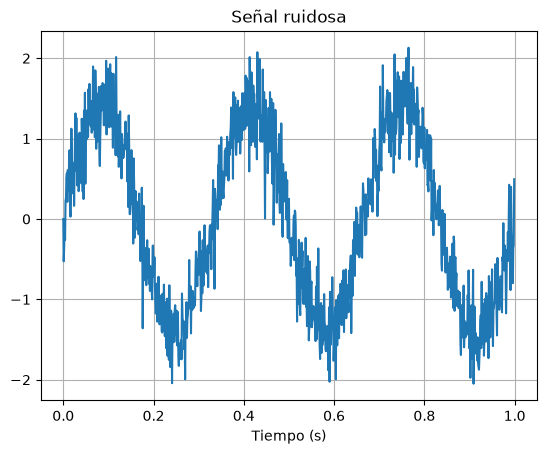

In [9]:
" ------------------------------------------------------- Gráficos --------------------------------------------------------"

#Grafico señal ruidosa
plt.plot(tt,noisy_xx)
plt.xlabel("Tiempo (s)")
plt.title("Señal ruidosa")
plt.grid()
plt.show()

Nota adicional: es interesante observar el gráfico de la secuencia de ruido aislada y cómo afecta a la gráfica de la señal original.


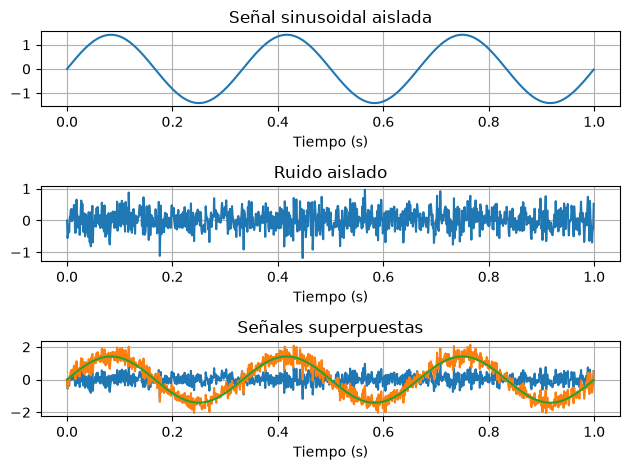

In [11]:
# Gráfico senoidal (arriba)
plt.subplot(3, 1, 1)
plt.plot(tt, xx)
plt.title("Señal sinusoidal aislada")
plt.xlabel("Tiempo (s)")
plt.grid()

# Gráfico ruido aislado
plt.subplot(3, 1, 2)
plt.plot(tt, ruido)
plt.title("Ruido aislado")
plt.xlabel("Tiempo (s)")
plt.grid()

# Gráfico completo
plt.subplot(3, 1, 3)
plt.plot(tt,ruido)
plt.plot(tt,noisy_xx)
plt.plot(tt,xx)
plt.title("Señales superpuestas")
plt.xlabel("Tiempo (s)")
plt.grid()

plt.tight_layout()
plt.show()